#  Exploration du Dataset — Flood Prediction
**Projet ML**  
Dataset : Kaggle Playground Series S4E5

---

## Installation des bibliothèques

In [ ]:
pip install numpy
pip install pandas
pip install matplotlib
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print('Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


## 2. Chargement des données

In [ ]:
df = pd.read_csv('train.csv')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

✅ Dataset chargé : 1,117,957 lignes × 22 colonnes


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


## 3. Vue d'ensemble du dataset

In [4]:
# Types de données et valeurs manquantes
info = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs nulles': df.isnull().sum(),
    'Valeurs uniques': df.nunique(),
    'Min': df.min(),
    'Max': df.max()
})
print(info.to_string())

                                    Type  Valeurs nulles  Valeurs uniques    Min          Max
id                                 int64               0          1117957  0.000  1117956.000
MonsoonIntensity                   int64               0               17  0.000       16.000
TopographyDrainage                 int64               0               19  0.000       18.000
RiverManagement                    int64               0               17  0.000       16.000
Deforestation                      int64               0               18  0.000       17.000
Urbanization                       int64               0               18  0.000       17.000
ClimateChange                      int64               0               18  0.000       17.000
DamsQuality                        int64               0               17  0.000       16.000
Siltation                          int64               0               17  0.000       16.000
AgriculturalPractices              int64               0    

In [5]:
# Statistiques descriptives
df.describe().round(3)

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,...,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000
mean,558978.000,4.921,4.927,4.955,4.942,4.943,4.934,4.956,4.928,4.943,...,4.947,4.954,4.931,4.929,4.926,4.928,4.951,4.941,4.939,0.504
std,322726.532,2.056,2.094,2.072,2.052,2.083,2.058,2.083,2.066,2.069,...,2.072,2.089,2.078,2.082,2.065,2.074,2.069,2.081,2.090,0.051
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.285
25%,279489.000,3.000,3.000,4.000,4.000,3.000,3.000,4.000,3.000,3.000,...,4.000,3.000,3.000,3.000,3.000,3.000,4.000,3.000,3.000,0.470
50%,558978.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,0.505
75%,838467.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,...,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,0.540
max,1117956.000,16.000,18.000,16.000,17.000,17.000,17.000,16.000,16.000,16.000,...,17.000,17.000,16.000,16.000,17.000,18.000,19.000,16.000,16.000,0.725


## 4. Analyse de la variable cible — FloodProbability

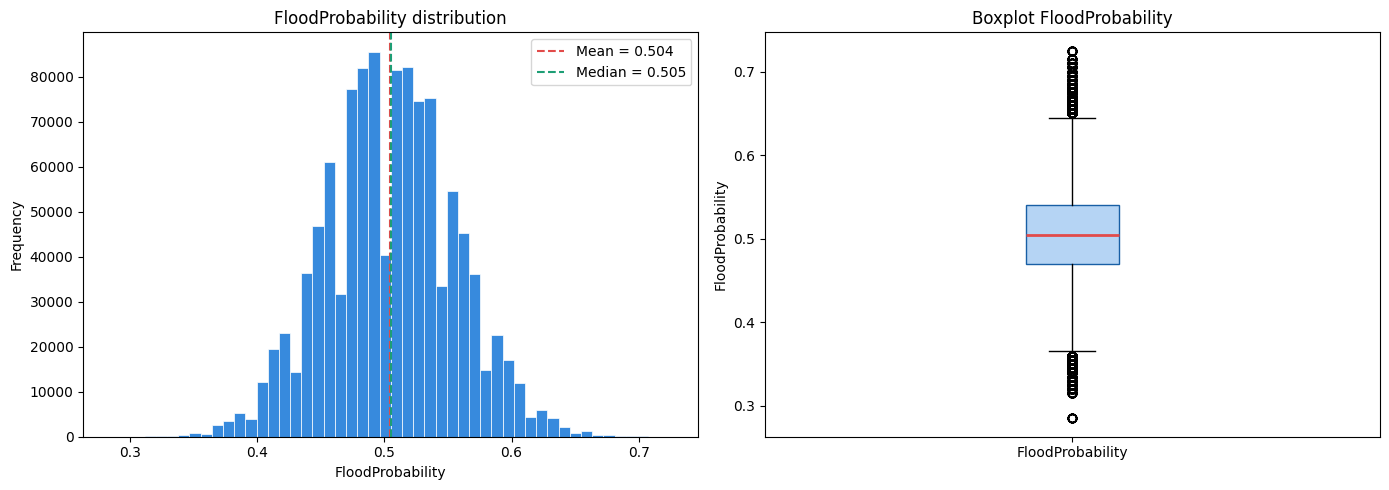


📊 Statistiques de FloodProbability :
   Mean  : 0.5045
   Median  : 0.5050
   Standard deviation: 0.0510
   Min      : 0.2850
   Max      : 0.7250



In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['FloodProbability'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('FloodProbability distribution')
axes[0].set_xlabel('FloodProbability')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['FloodProbability'].mean(), color='#E24B4A', linestyle='--', label=f"Mean = {df['FloodProbability'].mean():.3f}")
axes[0].axvline(df['FloodProbability'].median(), color='#1D9E75', linestyle='--', label=f"Median = {df['FloodProbability'].median():.3f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['FloodProbability'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                medianprops=dict(color='#E24B4A', linewidth=2))
axes[1].set_title('Boxplot FloodProbability')
axes[1].set_ylabel('FloodProbability')
axes[1].set_xticklabels(['FloodProbability'])

plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
 Statistiques de FloodProbability :
   Mean  : {df['FloodProbability'].mean():.4f}
   Median  : {df['FloodProbability'].median():.4f}
   Standard deviation: {df['FloodProbability'].std():.4f}
   Min      : {df['FloodProbability'].min():.4f}
   Max      : {df['FloodProbability'].max():.4f}
""")

## 5. Distribution des variables explicatives

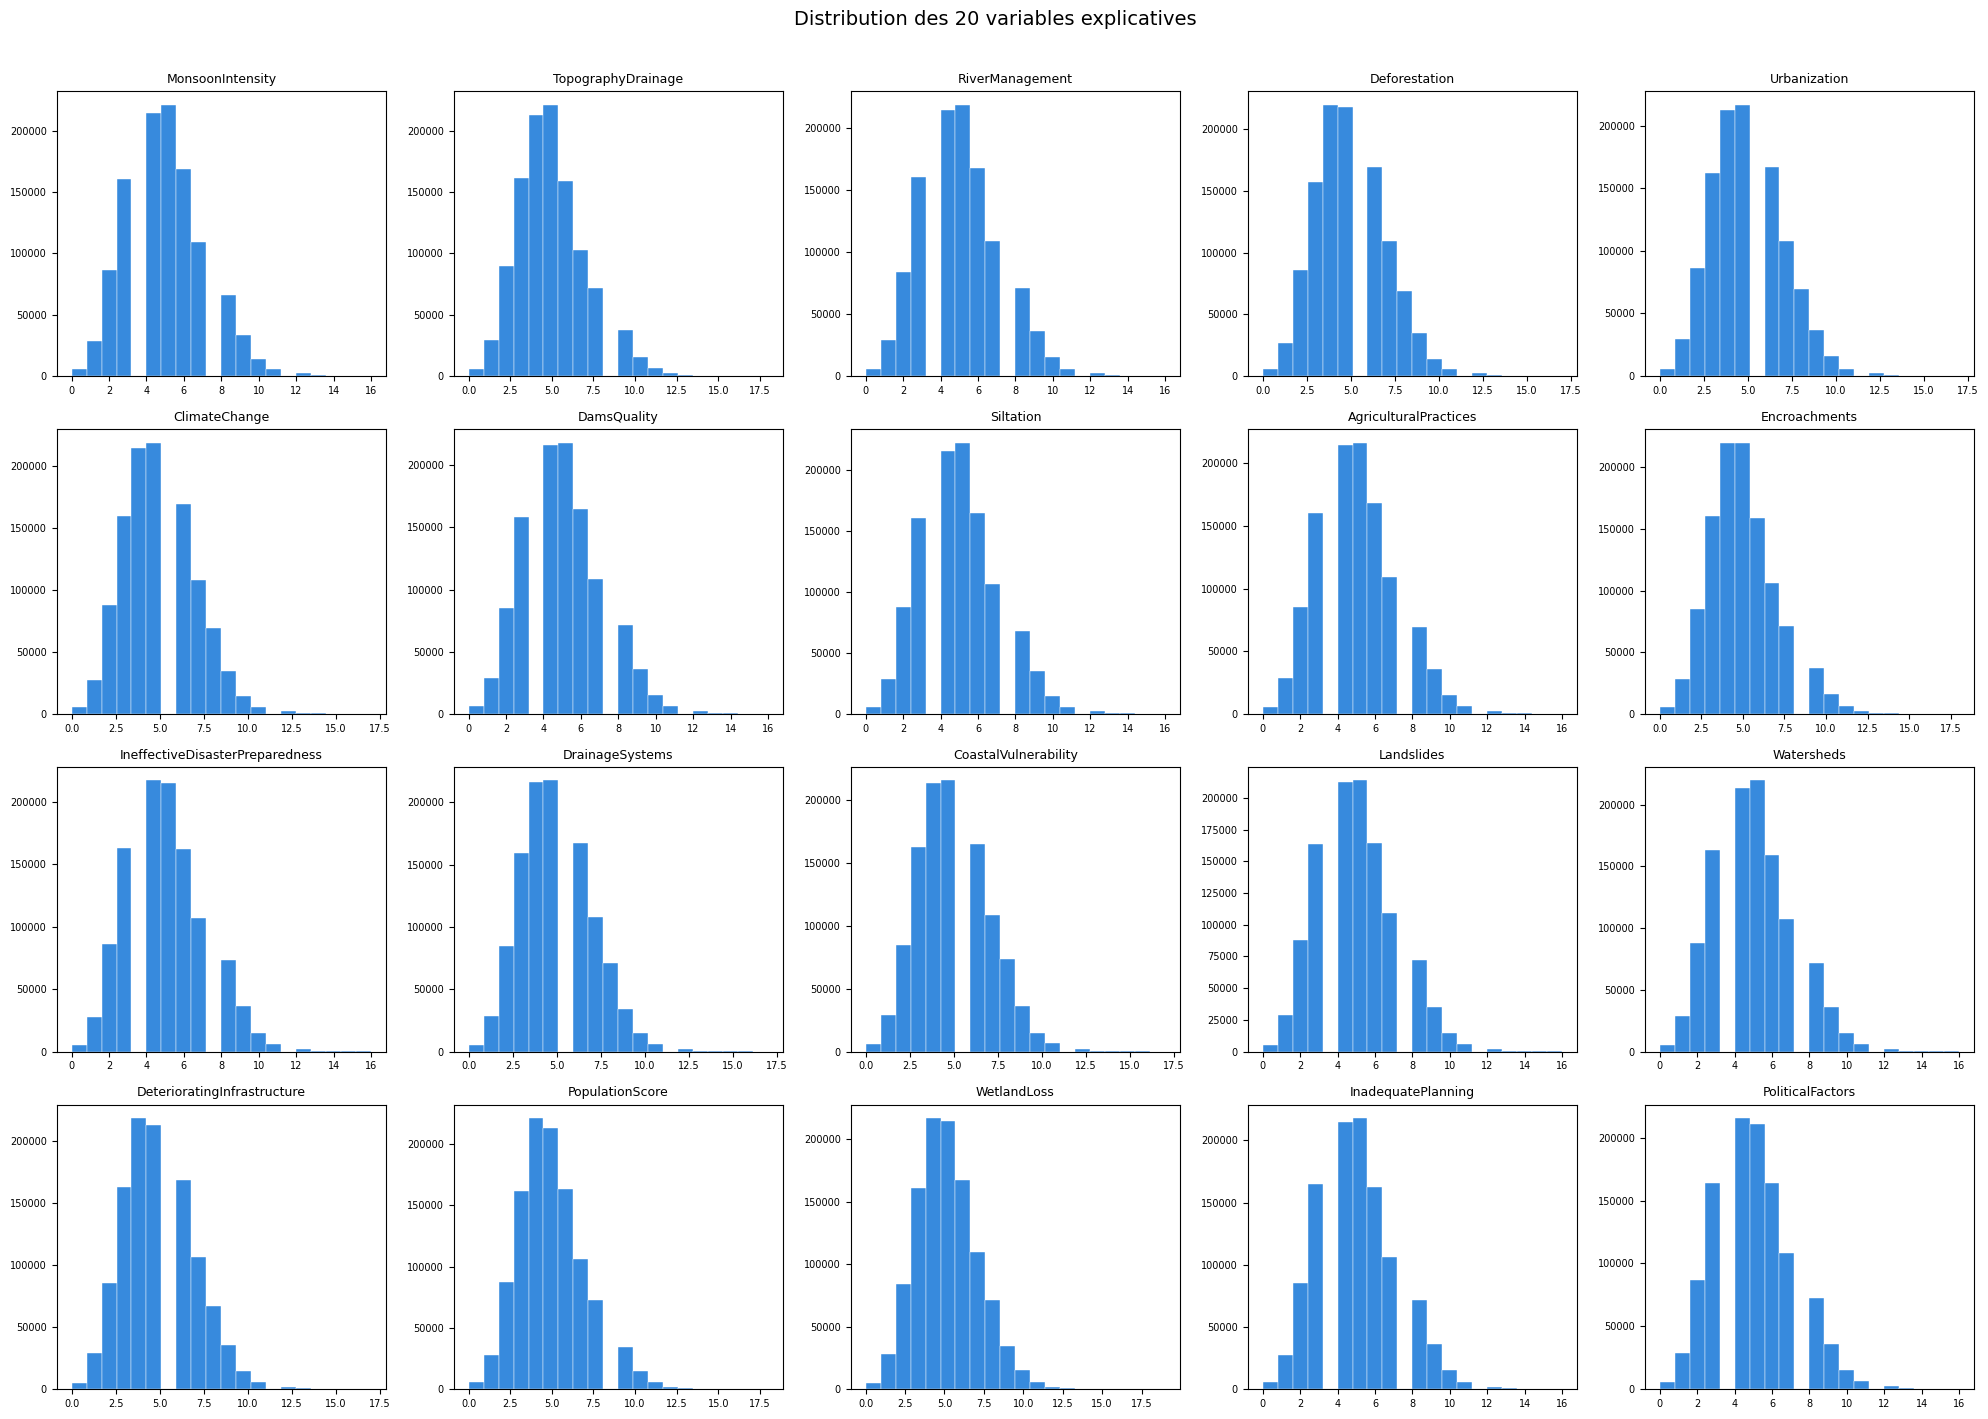

✅ Toutes les variables ont une distribution proche du normale — pas de transformation nécessaire


In [ ]:
features = [c for c in df.columns if c not in ['id', 'FloodProbability']]

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, color='#378ADD', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

plt.suptitle('Distribution des 20 variables explicatives', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Toutes les variables ont une distribution proche du normale — pas de transformation nécessaire')

## 6. Corrélations avec la variable cible

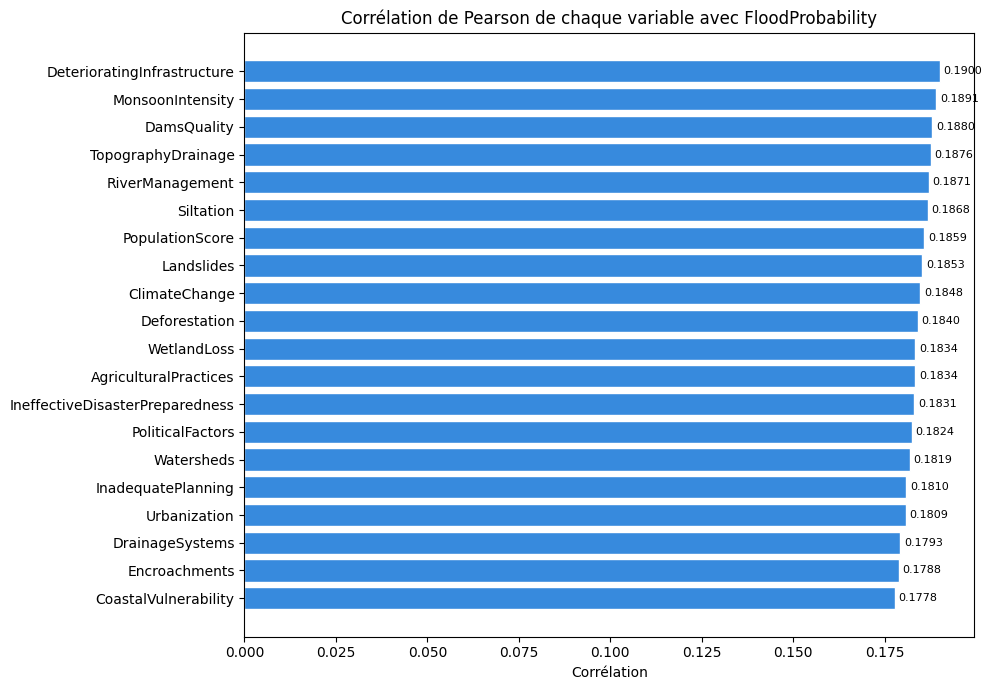

🔝 Variable la plus corrélée : DeterioratingInfrastructure (0.1900)
⬇️  Variable la moins corrélée : CoastalVulnerability (0.1778)


In [ ]:
# Corrélation de chaque variable avec FloodProbability
corr_target = df[features + ['FloodProbability']].corr()['FloodProbability'].drop('FloodProbability').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#378ADD' if v > 0 else '#E24B4A' for v in corr_target]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Corrélation de Pearson de chaque variable avec FloodProbability')
ax.set_xlabel('Corrélation')

# Valeurs sur les barres
for bar, val in zip(bars, corr_target.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f' Variable la plus corrélée : {corr_target.idxmax()} ({corr_target.max():.4f})')
print(f'⬇  Variable la moins corrélée : {corr_target.idxmin()} ({corr_target.min():.4f})')

## 7. Heatmap de corrélation complète

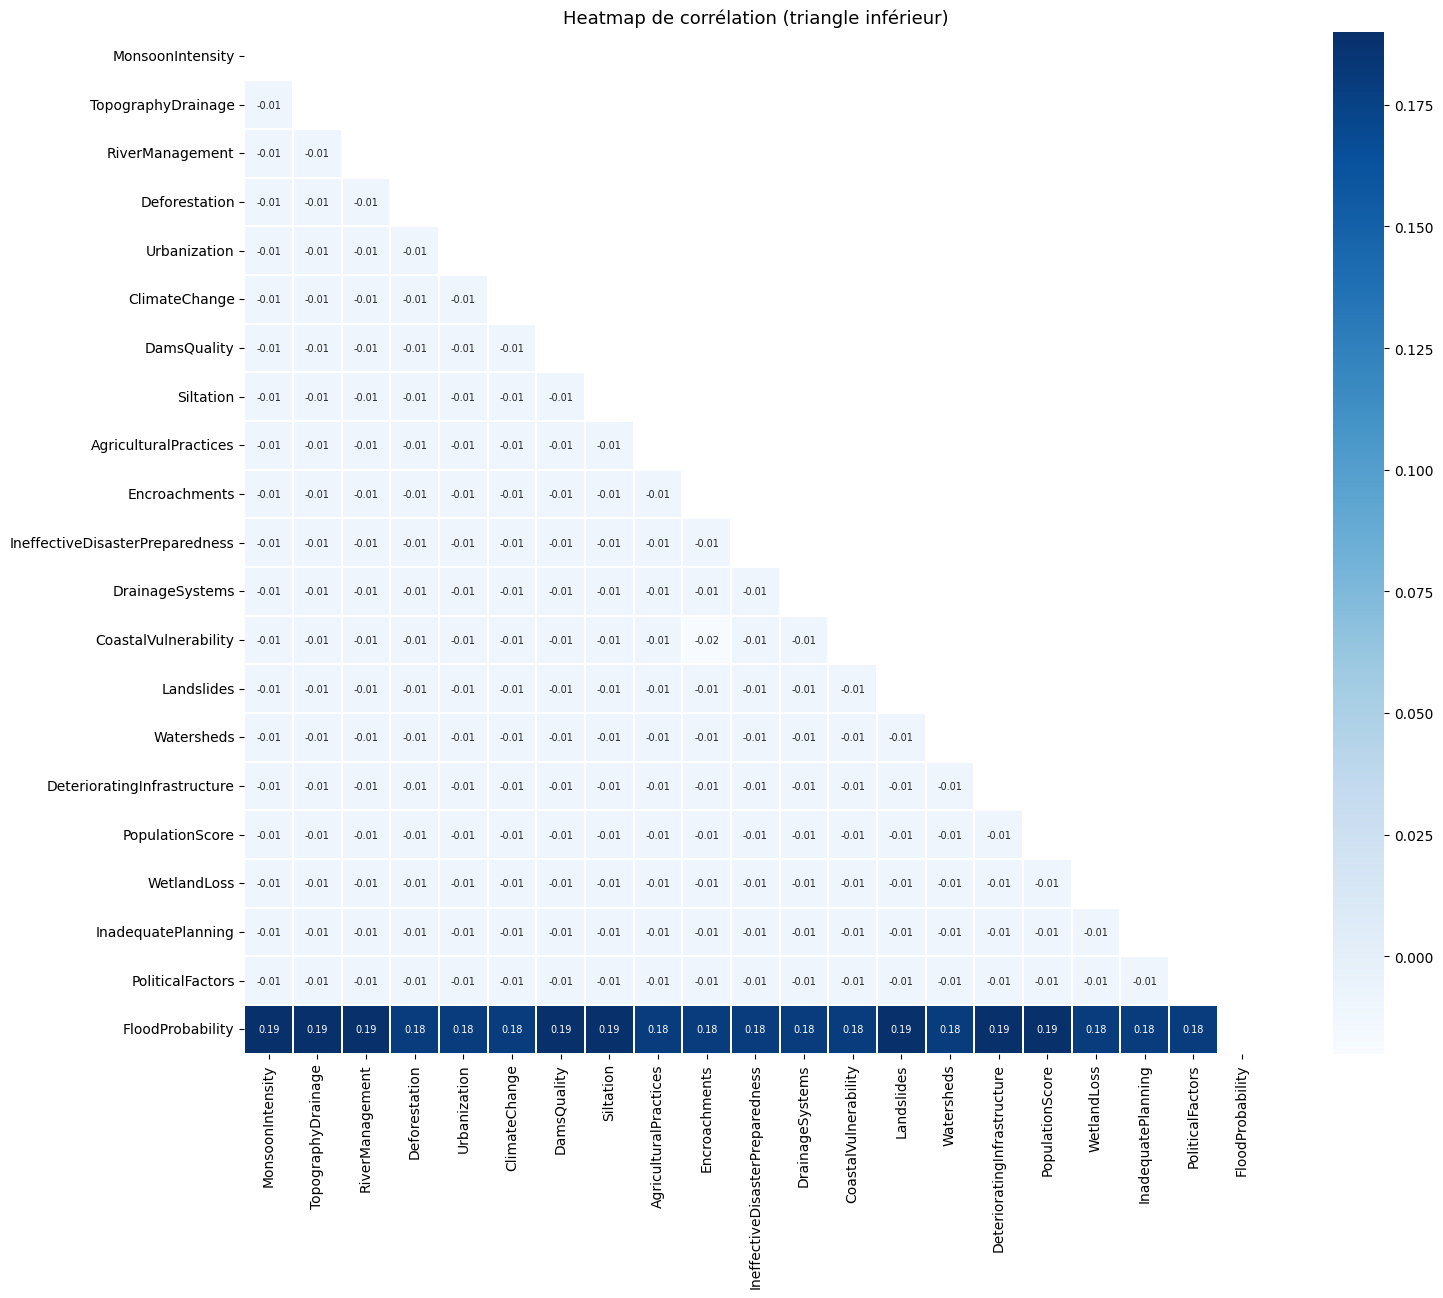

✅ Aucune forte multicolinéarité détectée entre les variables explicatives


In [ ]:
import numpy as np
import seaborn as sns
corr_matrix = df[features + ['FloodProbability']].corr().round(2)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masque triangle supérieur
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=ax,
    linewidths=0.3,
    annot_kws={'size': 7},
    square=True
)
ax.set_title('Heatmap de corrélation (triangle inférieur)', fontsize=13)
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Aucune forte multicolinéarité détectée entre les variables explicatives')

## 8. Relation entre quelques variables et la cible

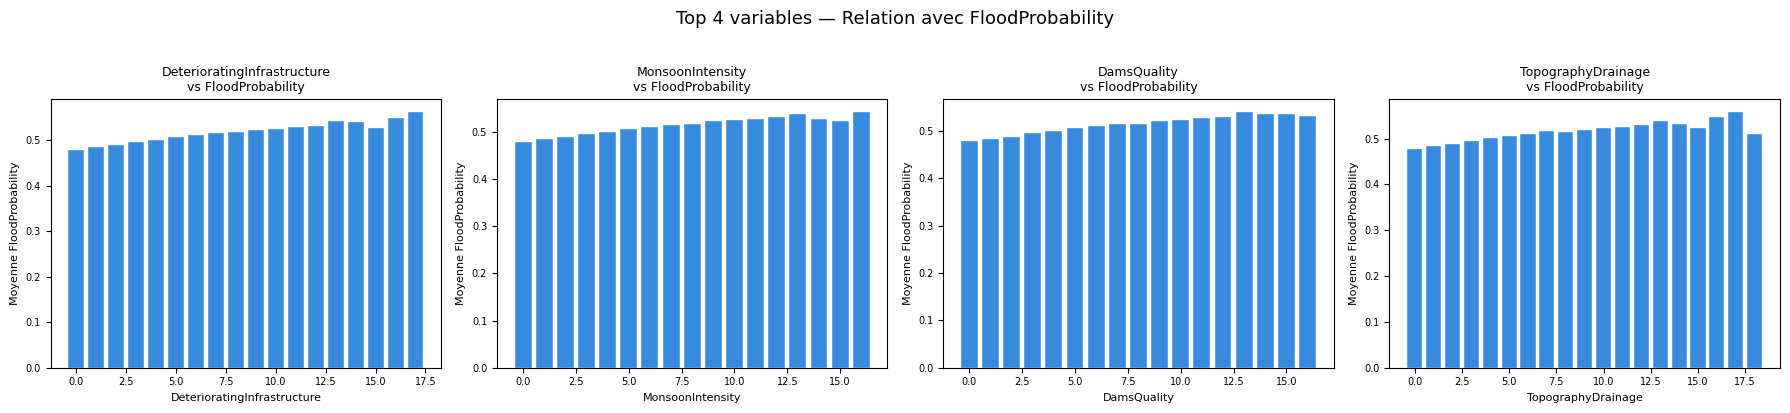

In [19]:
top_features = corr_target.sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(top_features):
    # Moyenne de FloodProbability par valeur de la variable
    group = df.groupby(col)['FloodProbability'].mean()
    axes[i].bar(group.index, group.values, color='#378ADD', edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{col}\nvs FloodProbability', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Moyenne FloodProbability', fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Top 4 variables — Relation avec FloodProbability', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Préparation des données

## Installation de la librairie scikit-learn

In [28]:
%pip install sKlearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [ ]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

# Séparation features / cible
features = [c for c in df.columns if c not in ['id', 'FloodProbability']]
X = df[features]
y = df['FloodProbability']

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Données prêtes pour la modélisation :')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   y_train : {y_train.shape}')
print(f'   y_test  : {y_test.shape}')
print('\n Prêt pour entraîner les modèles ML !')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Données prêtes pour la modélisation :
   X_train : (894365, 20)
   X_test  : (223592, 20)
   y_train : (894365,)
   y_test  : (223592,)

🚀 Prêt pour entraîner les modèles ML !


In [1]:
import pandas
import numpy
import matplotlib
import seaborn
import sklearn

print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.3.2
numpy: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
scikit-learn: 1.8.0
